# Early stopping patience

### Assumption

Early stopping patience defines the maximum amount of training epochs without improvement in validation loss before the training process gets stopped.

Regarding the total of 50 Epochs of training in our example, i selected the following values:

* 1: Extremely impatient - I expect a low validation accuracy, especially because the reduced learning rate will not apply in this case, as it has higher       patience than the early stopping

* 5: Standard Value - I expect a high accuracy for this value, it fits the standard of ~ 10% patience compared to total Training epochs and the model will profit from reduced learning rate(fine tuning) at least once in this case

* 10: Patient Standard Value - I expect this model to yield the highest validation accuracy. 20% patience is still close to the standard and the fine tuning with reduced learning rate will be applied for more rounds, which might increase the accuracy even more

* 25: Extremely patient - 50% patience is above standard and might lead to overfitting - I expect this model to yield high training accuracy, but slightly inferior validation accuracy. Also the learning rate reduction will apply often and the model might get stuck on a pleateau.

* 50: No early stopping - 100% Patience is basically no early stopping, the model will be trained for the full 50 epochs. I expect it to severly overfit, yielding very high training accuracy but inferior validation accuracy. It is very likely to get stuck on a plateau, as the learning rate reduction will apply often.

Regarding the prediction inference time, i dont expect any significant differences between the models. This is because early stopping only controls the duration of the training phase, not the model architecture itself.

In [149]:
import cv2
import json
from matplotlib import pyplot as plt
import numpy as np
import os
import random
import time

# import a lot of things from keras:
# sequential model
from keras.models import Sequential

# layers
from keras.layers import Input, Dense, Dropout, Flatten, Conv2D, MaxPooling2D, RandomFlip, RandomRotation, RandomContrast, RandomBrightness

# loss function
from keras.metrics import categorical_crossentropy

# callback functions
from keras.callbacks import ReduceLROnPlateau, EarlyStopping

# convert data to categorial vector representation
from keras.utils import to_categorical

# nice progress bar for loading data
from tqdm.notebook import tqdm

# helper function for train/test split
from sklearn.model_selection import train_test_split 

# import confusion matrix helper function
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# import pre-trained model
from keras.applications.vgg16 import VGG16

# include only those gestures
CONDITIONS = ['like', 'stop']

# image size
IMG_SIZE = 64
SIZE = (IMG_SIZE, IMG_SIZE)

# number of color channels we want to use
# set to 1 to convert to grayscale
# set to 3 to use color images
COLOR_CHANNELS = 3

PATH = '../gesture_dataset_sample'

## helper function to load and parse annotations

In [150]:
annotations = dict()

for condition in CONDITIONS:
    with open(f'{PATH}/_annotations/{condition}.json') as f:
        annotations[condition] = json.load(f)

In [151]:
# pretty-print first element
#000484ab-5fd0-49b8-9253-23a22b71d7b1
print(json.dumps(annotations['like']['0014182f-d756-42b3-896c-c52de76926bb'], indent=2))

{
  "bboxes": [
    [
      0.38056273,
      0.35650891,
      0.17322347,
      0.10461114
    ]
  ],
  "labels": [
    "like"
  ],
  "landmarks": [
    [
      [
        0.5497169170918876,
        0.4276043615779976
      ],
      [
        0.5218336293004483,
        0.40536586667786917
      ],
      [
        0.48288133220125257,
        0.3930262243722419
      ],
      [
        0.4501841862302019,
        0.37981099195030416
      ],
      [
        0.44251365410099686,
        0.36620499322043343
      ],
      [
        0.43138297470865106,
        0.406093902776592
      ],
      [
        0.4072660997339628,
        0.4073950234480344
      ],
      [
        0.42588200316326846,
        0.40612291879594015
      ],
      [
        0.4441470003072778,
        0.4049221293588555
      ],
      [
        0.4314493576491367,
        0.4212979654419442
      ],
      [
        0.42096276272263283,
        0.4180224457320293
      ],
      [
        0.43966095717106257,
      

## helper function to pre-process images (color channel conversion and resizing)

In [152]:
def preprocess_image(img):
    if COLOR_CHANNELS == 1:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img, SIZE)
    return img_resized

## load images and annotations

In [153]:
images = [] # stores actual image data
labels = [] # stores labels (as integer - because this is what our network needs)
label_names = [] # maps label ints to their actual categories so we can understand predictions later

# loop over all conditions
# loop over all files in the condition's directory
# read the image and corresponding annotation
# crop image to the region of interest
# preprocess image
# store preprocessed image and label in corresponding lists
for condition in CONDITIONS:
    for filename in tqdm(os.listdir(f'{PATH}/{condition}')):
        # extract unique ID from file name
        UID = filename.split('.')[0]
        img = cv2.imread(f'{PATH}/{condition}/{filename}')
        
        # get annotation from the dict we loaded earlier
        try:
            annotation = annotations[condition][UID]
        except Exception as e:
            print(e)
            continue
        
        # iterate over all hands annotated in the image
        for i, bbox in enumerate(annotation['bboxes']):
            # annotated bounding boxes are in the range from 0 to 1
            # therefore we have to scale them to the image size
            x1 = int(bbox[0] * img.shape[1])
            y1 = int(bbox[1] * img.shape[0])
            w = int(bbox[2] * img.shape[1])
            h = int(bbox[3] * img.shape[0])
            x2 = x1 + w
            y2 = y1 + h
            
            # crop image to the bounding box and apply pre-processing
            crop = img[y1:y2, x1:x2]
            preprocessed = preprocess_image(crop)
            
            # get the annotated hand's label
            # if we have not seen this label yet, add it to the list of labels
            label = annotation['labels'][i]
            if label not in label_names:
                label_names.append(label)
            
            label_index = label_names.index(label)
            
            images.append(preprocessed)
            labels.append(label_index)

  0%|          | 0/250 [00:00<?, ?it/s]

  0%|          | 0/250 [00:00<?, ?it/s]

## let's have a look at one of the images

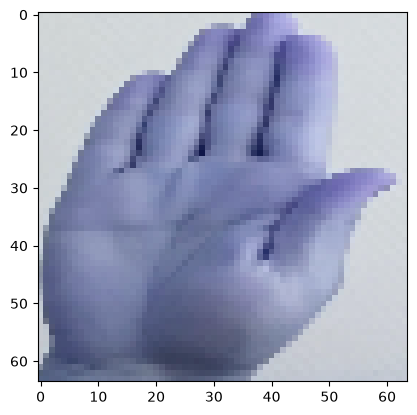

In [154]:
plt.imshow(random.sample(images, 1)[0])
#plt.imshow(random.sample(images, 1)[0], cmap='gray')

## split data set into train and test

In [155]:
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

512
128
512
128


## transform data sets into a format compatible with our neural network

In [156]:
# Convert to float
X_train = np.array(X_train).astype('float32')
# Normalization [0,1]
X_train = X_train / 255.

X_test = np.array(X_test).astype('float32')
X_test = X_test / 255.


# Convert interger class labels in to one hot vector
y_train_one_hot = to_categorical(y_train)
y_test_one_hot = to_categorical(y_test)

# rename for demonstration purposes
train_label = y_train_one_hot
test_label = y_test_one_hot

X_train = X_train.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)
X_test = X_test.reshape(-1, IMG_SIZE, IMG_SIZE, COLOR_CHANNELS)

print(X_train.shape, X_test.shape, train_label.shape, test_label.shape)

(512, 64, 64, 3) (128, 64, 64, 3) (512, 3) (128, 3)


In [157]:
# variables for hyperparameters
batch_size = 8 
epochs = 50 
num_classes = len(label_names)
activation = 'relu'
activation_conv = 'leaky_relu'
layer_count = 2
num_neurons = 64

# define model structure
# with keras, we can use a model's add() function to add layers to the network one by one
model = Sequential()

# data augmentation (this can also be done beforehand - but don't augment the test dataset!)
model.add(RandomFlip('horizontal'))
model.add(RandomContrast(0.1))
#model.add(RandomBrightness(0.1))
#model.add(RandomRotation(0.2))

# first, we add some convolution layers followed by max pooling
model.add(Conv2D(64, kernel_size=(9, 9), activation=activation_conv, input_shape=(SIZE[0], SIZE[1], COLOR_CHANNELS), padding='same'))
model.add(MaxPooling2D(pool_size=(4, 4), padding='same'))

model.add(Conv2D(32, (5, 5), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), padding='same'))

model.add(Conv2D(32, (3, 3), activation=activation_conv, padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), padding='same'))

# Randomly disables 20% of neurons during each training step
model.add(Dropout(0.2))

# after the convolution layers, we have to flatten the data so it can be fed into fully connected layers
model.add(Flatten())

# add some fully connected layers ("Dense")
for i in range(layer_count - 1):
    model.add(Dense(num_neurons, activation=activation))

model.add(Dense(num_neurons, activation=activation))

# for classification, the last layer has to use the softmax activation function, which gives us probabilities for each category
model.add(Dense(num_classes, activation='softmax'))

# specify loss function, optimizer and evaluation metrics
# for classification, categorial crossentropy is used as a loss function
# use the adam optimizer unless you have a good reason not to
model.compile(loss=categorical_crossentropy, optimizer="adam", metrics=['accuracy'])

# define callback functions that react to the model's behavior during training
# in this example, we reduce the learning rate once we get stuck and early stopping
# to cancel the training if there are no improvements for a certain amount of epochs

# If validation loss stops improving for 2 epochs, multiply  the learning rate by 0.2 (slow down/fine tune)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.0001)
# if validation loss doesn't improve for 3 epchs, stop training entierly
stop_early = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights = True)

## now, we can train the model using the fit() function

In [158]:
history = model.fit(
    X_train,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(X_test, test_label),
    callbacks=[reduce_lr, stop_early]
)

Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4062 - loss: 1.0558 - val_accuracy: 0.4297 - val_loss: 1.0325 - learning_rate: 0.0010
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5664 - loss: 0.9297 - val_accuracy: 0.6016 - val_loss: 0.8231 - learning_rate: 0.0010
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6113 - loss: 0.8586 - val_accuracy: 0.6172 - val_loss: 0.7829 - learning_rate: 0.0010
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7012 - loss: 0.7056 - val_accuracy: 0.6406 - val_loss: 0.8930 - learning_rate: 0.0010


## Model accuracy and prediction inference time

In [159]:
start = time.time()
predictions = model.predict(X_test)
end = time.time()
inference_time = (end - start) / len(predictions)

train_loss, train_acc = model.evaluate(X_train, train_label, verbose = 0)
val_loss, val_acc = model.evaluate(X_test, test_label, verbose = 0)

# final model refers to the model with the best accuracy, that is restored after stopping using the restore_best_weights=True flag for EarlyStopping
print(f"Final Model - Training Accuracy:{train_acc:.2f}")
print(f"Final Model - Validation Accuracy:{val_acc:.2f}")
print(f"inference time per prediction: {inference_time:.6f}")
print("Number of Epochs trained:", len(history.history['val_accuracy']))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Final Model - Training Accuracy:0.65
Final Model - Validation Accuracy:0.62
inference time per prediction: 0.000676
Number of Epochs trained: 4


## Plot of Resulting Validation Accuracy and Training Epochs

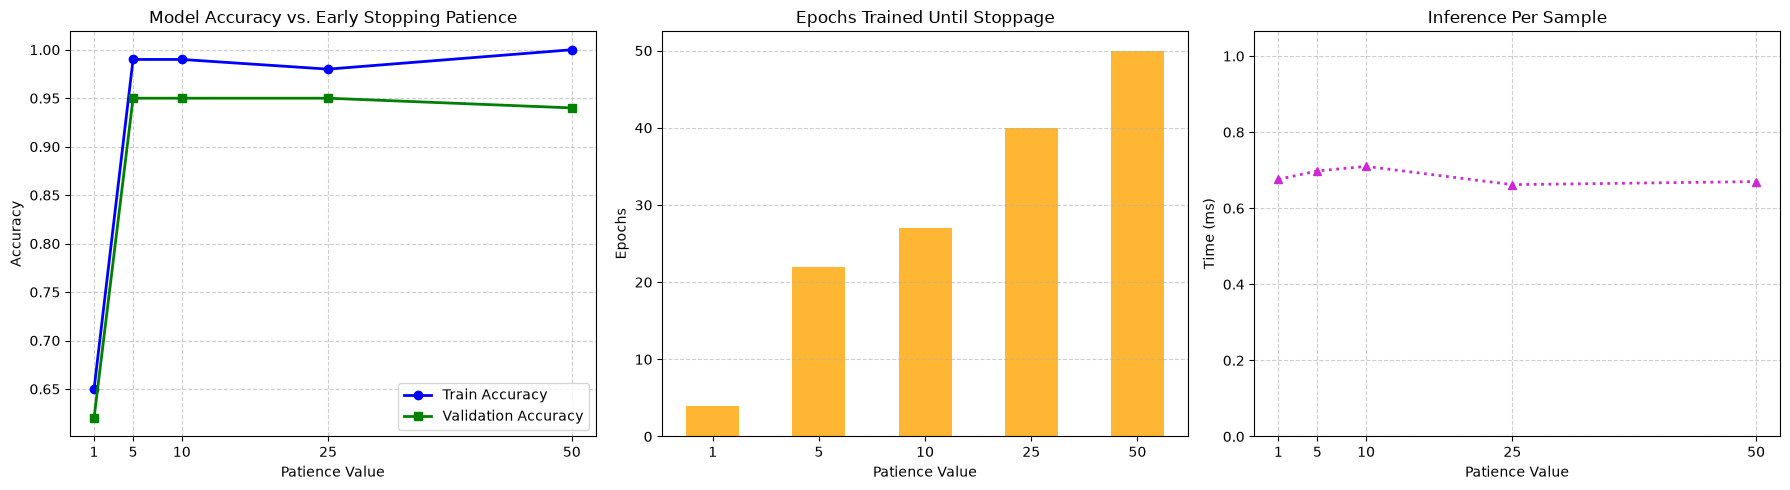

In [ ]:
values = [1, 5, 10, 25, 50]
train_accuracies = [0.65, 0.99, 0.99, 0.98, 1]
val_accuracies = [0.62, 0.95, 0.95, 0.95, 0.94] 
inference = [0.000676, 0.000698, 0.000710, 0.000662, 0.000670]
inference_ms = [t * 1000 for t in inference]
num_epochs = [4, 22, 27, 40, 50]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1
ax1.plot(values, train_accuracies, marker='o', label='Train Accuracy', color='blue', linewidth=2)
ax1.plot(values, val_accuracies, marker='s', label='Validation Accuracy', color='green', linewidth=2)
ax1.set_title('Model Accuracy vs. Early Stopping Patience')
ax1.set_xlabel('Patience Value')
ax1.set_ylabel('Accuracy')
ax1.set_xticks(values)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Plot 2
ax2.bar([str(v) for v in values], num_epochs, color='orange', alpha=0.8, width=0.5)
ax2.set_title('Epochs Trained Until Stoppage')
ax2.set_xlabel('Patience Value')
ax2.set_ylabel('Epochs')
ax2.grid(True, axis='y', linestyle='--', alpha=0.6)

# Plot 3
ax3.plot(values, inference_ms, marker='^', color="#d027d6", linewidth=2, linestyle=':')
ax3.set_title('Inference Per Sample')
ax3.set_xlabel('Patience Value')
ax3.set_ylabel('Time (ms)')
ax3.set_xticks(values)
ax3.set_ylim(0, max(inference_ms) * 1.5) 
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## Result Discussion

Looking at the Accuracy results, they mostly came out as expected.  

A Patience of 1 is way too aggressive and does not give the Model enough time to adjust the training parameters.  

The accuracies for the other 4 values were fairly similar, with values 5, 10 and 25 leading with 95% Validation Accuracy.  

When taking the amount of training epochs into account, the patience of 5 comes out as superior, as it achieved the highest accuracy with less training epochs than the patience values of 10 and 25.

The Patience of 25 did not overfit as much as expected and it achieved the highest validation accuracy, but in terms of training time it fell short.

A Patience of 50 had, as expected, the biggest difference between training and validation accuracy, because the model was overfitted on the training data.

The inference time was almost constant throughout all models, ranging between [0.000662, 0.000710]. These differences are very small and likely due to processing noise.